# Visualization & Analysis

This notebook loads the extracted features and produces:
- Feature inspection (ranked sounds per feature)
- Boxplots: F0 and spectral centroid by group (A vs J)
- PCA of MFCC features
- K-Means clustering (unsupervised, k=2)

## Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Load Data

In [2]:
outputs_folder = "../outputs"
figures_folder = "../figures"
os.makedirs(figures_folder, exist_ok=True)

data = []
for sound_folder in os.listdir(outputs_folder):
    json_path = os.path.join(outputs_folder, sound_folder, "results.json")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            result = json.load(f)
            result["file"] = sound_folder
            result["group"] = sound_folder[0]
            data.append(result)

df = pd.DataFrame(data)
print(f"Loaded {len(df)} sounds")
df.head()

Loaded 52 sounds


,file,duration,global_intensity,f0_mean,f0_variability,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,mfcc_mean,group
0,A17,1.500023,0.038223,153.082832,72.278269,2498.376197,2448.852118,4669.889198,"[-268.4269104003906, 186.66883850097656, -100....",A
1,A15,1.500045,0.039969,177.602151,81.065714,2423.793932,2527.907365,4826.584660,"[-266.69189453125, 186.16000366210938, -87.469...",A
2,J8,1.500000,0.043682,135.338844,86.412480,1683.752403,1508.542672,2755.918720,"[-292.8818359375, 242.25575256347656, -94.3273...",J
3,J18,1.500000,0.042461,232.198165,139.605847,3018.489902,1639.247107,4305.518617,"[-400.82855224609375, 242.2602996826172, -53.2...",J
4,J3,1.500000,0.040108,198.459007,166.081423,2365.620693,1758.312205,3767.151067,"[-253.87655639648438, 195.61439514160156, -129...",J


## Feature Inspection

In [3]:
df_sorted_f0 = df.sort_values(by="f0_mean", ascending=False)
df_sorted_centroid = df.sort_values(by="spectral_centroid_mean", ascending=False)
df_sorted_bandwidth = df.sort_values(by="spectral_bandwidth_mean", ascending=False)
df_sorted_rolloff = df.sort_values(by="spectral_rolloff_mean", ascending=False)

print("Highest F0:"); print(df_sorted_f0[["file", "f0_mean"]].head(3).to_string(index=False))
print("\nHighest spectral centroid:"); print(df_sorted_centroid[["file", "spectral_centroid_mean"]].head(3).to_string(index=False))
print("\nLowest F0:"); print(df_sorted_f0[["file", "f0_mean"]].tail(3).to_string(index=False))
print("\nLowest spectral centroid:"); print(df_sorted_centroid[["file", "spectral_centroid_mean"]].tail(3).to_string(index=False))

# Save inspection JSON
inspection_results = {
    "highest_f0": df_sorted_f0[["file", "f0_mean"]].head(5).to_dict(orient="records"),
    "lowest_f0": df_sorted_f0[["file", "f0_mean"]].tail(5).to_dict(orient="records"),
    "highest_spectral_centroid": df_sorted_centroid[["file", "spectral_centroid_mean"]].head(5).to_dict(orient="records"),
    "lowest_spectral_centroid": df_sorted_centroid[["file", "spectral_centroid_mean"]].tail(5).to_dict(orient="records"),
    "highest_spectral_bandwidth": df_sorted_bandwidth[["file", "spectral_bandwidth_mean"]].head(5).to_dict(orient="records"),
    "lowest_spectral_bandwidth": df_sorted_bandwidth[["file", "spectral_bandwidth_mean"]].tail(5).to_dict(orient="records"),
    "highest_spectral_rolloff": df_sorted_rolloff[["file", "spectral_rolloff_mean"]].head(5).to_dict(orient="records"),
    "lowest_spectral_rolloff": df_sorted_rolloff[["file", "spectral_rolloff_mean"]].tail(5).to_dict(orient="records")
}
with open("../outputs/feature_inspection.json", "w") as f:
    json.dump(inspection_results, f, indent=4)
print("\nFeature inspection JSON saved")

Highest F0:
file    f0_mean
 J21 443.329615
 J26 440.971992
 J24 440.303943

Highest spectral centroid:
file  spectral_centroid_mean
 J23             3082.449785
 J22             3071.324966
 J25             3059.090960

Lowest F0:
file    f0_mean
 A11 133.956327
 A23 120.365753
 A22 119.143413

Lowest spectral centroid:
file  spectral_centroid_mean
  A8             1462.277867
 A22             1382.109020
 A23             1305.430443

Feature inspection JSON saved


## Boxplots by Group

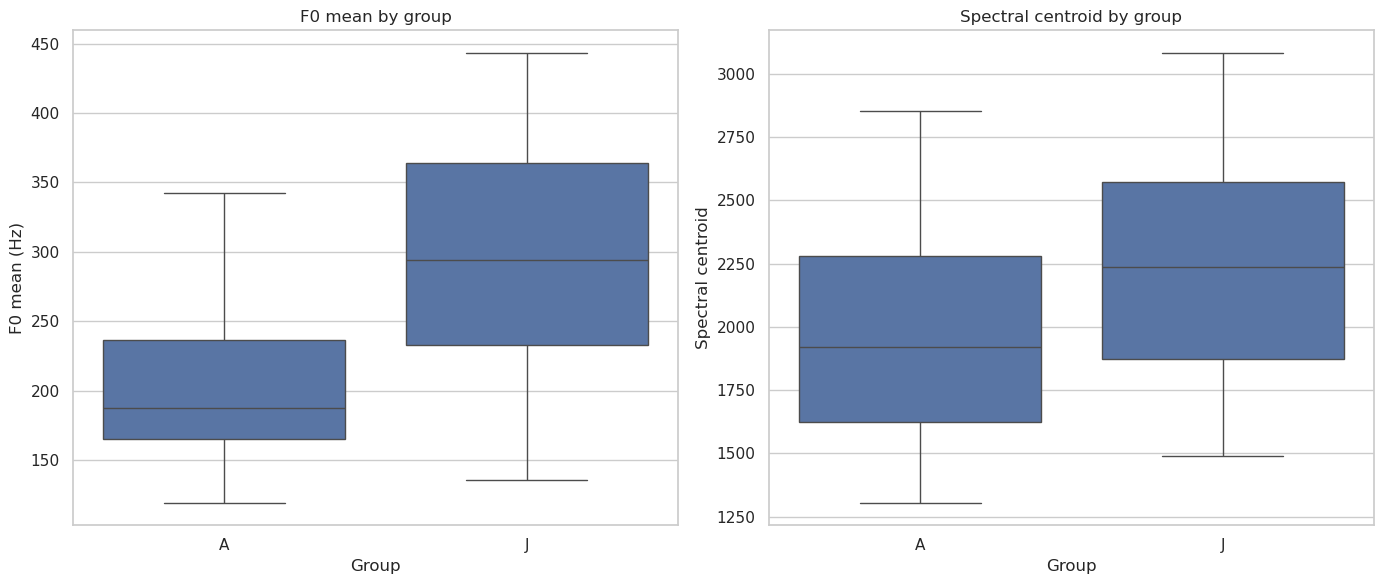

In [4]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x="group", y="f0_mean", ax=axes[0])
axes[0].set_title("F0 mean by group")
axes[0].set_xlabel("Group")
axes[0].set_ylabel("F0 mean (Hz)")

sns.boxplot(data=df, x="group", y="spectral_centroid_mean", ax=axes[1])
axes[1].set_title("Spectral centroid by group")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("Spectral centroid")

plt.tight_layout()
plt.savefig("../figures/boxplots_by_group.png", dpi=150)
plt.show()

## PCA on MFCC Features

Variance explained: PC1=42.2%, PC2=25.4%


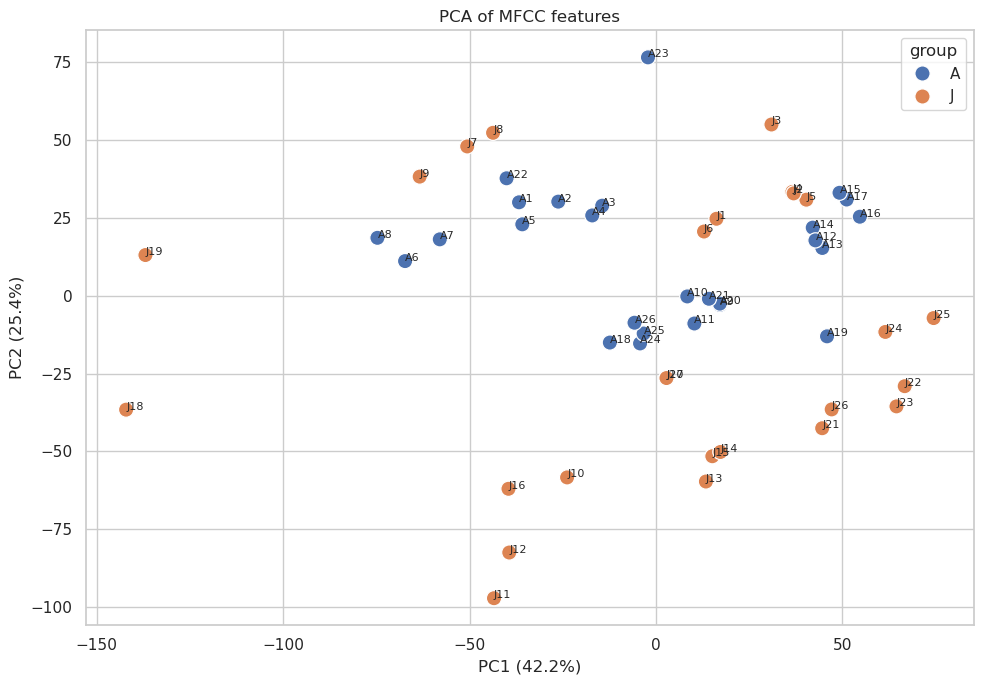

In [5]:
mfcc_data = [item["mfcc_mean"] for item in data]
labels = [item["group"] for item in data]
files = [item["file"] for item in data]

X = np.array(mfcc_data)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame({
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    "group": labels,
    "file": files
})

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x="pc1", y="pc2", hue="group", s=120)
for i, row in df_pca.iterrows():
    plt.text(row["pc1"], row["pc2"], row["file"], fontsize=8)
plt.title("PCA of MFCC features")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.tight_layout()
plt.savefig("../figures/pca_mfcc_individual.png", dpi=150)
plt.show()

## K-Means Clustering

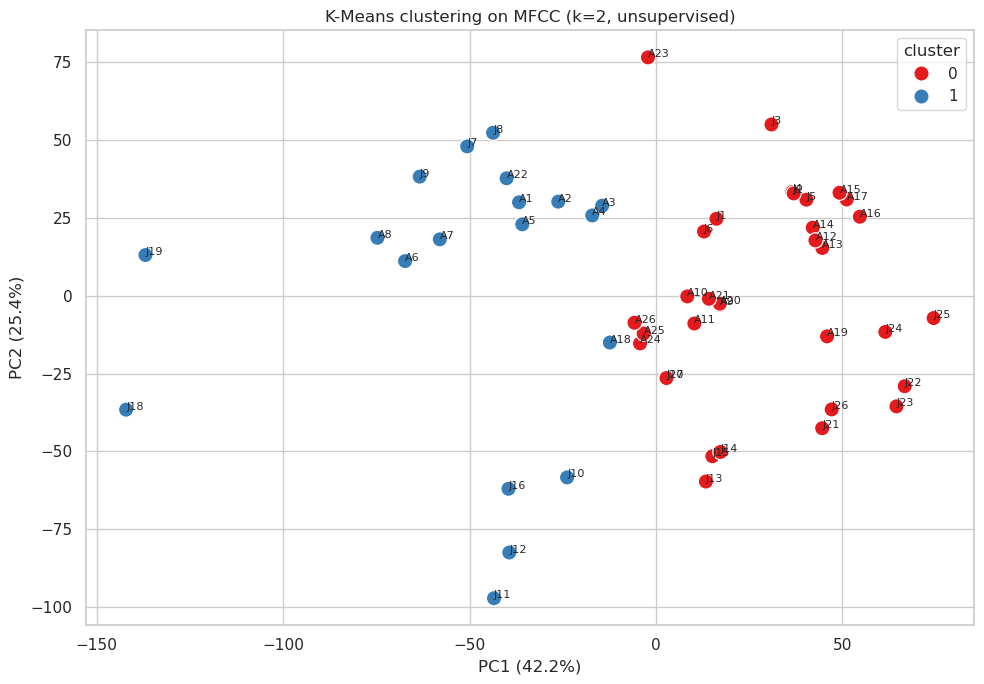

Done — all figures saved


In [6]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)
df_pca["cluster"] = clusters.astype(str)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x="pc1", y="pc2", hue="cluster", palette="Set1", s=120)
for i, row in df_pca.iterrows():
    plt.text(row["pc1"], row["pc2"], row["file"], fontsize=8)
plt.title("K-Means clustering on MFCC (k=2, unsupervised)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.tight_layout()
plt.savefig("../figures/kmeans_mfcc.png", dpi=150)
plt.show()

print("Done — all figures saved")